<a href="https://colab.research.google.com/github/emsofjames2003/CB2330-exercises/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##instruktioner

**The data object**: table 1: number of participants, mean, standard deviation and relative number of reported contacts.

**The random variable chosen**: X = total number of social contacts under one day reported by an average individual

**What the paper does**: The paper presents a population-based prospective survey, where 7290 participants recorded their mixing patterns (social contacts)for one day. Different types of contacts were identified, and different parameters are associated with different average rates of contact. The categories recorded were age, day of the week, gender, country, and household size.

 The purpose of the survey is to allow modelling of transmission of infectious diseases that spread through close-contact.

**The generative model proposed**: Negative Binomail Distribution

We chose this as contacts are independent with rates of daily contacts varying from person to person.

**Parameters and assumptions**:  θ = age. We assume that age is the most important predictor of the mean daily contact rate.

**The forward simulation**:

**The parametrization/fitting**:

**What/if the model adds to the paper**:

**Model limitations/how it breaks**: The limitation of our model is that we only include age, and leave out other important factors, such as household size, day of week, gender, and country.

**The article**

### Mossong et al. (2008), *Social Contacts and Mixing Patterns Relevant to the Spread of Infectious Diseases*.

https://doi.org/10.1371/journal.pmed.0050074

Our question: How much does the average number of daily contacts differ between people aged 10-14 and those aged 70 or older?

**The data object:**

We use the results for two age groups from Table 1:

| Age group | Number of participants | Mean daily contacts | Standard deviation |
|---|---:|---:|---:|
| 10–14 year-olds | 713 | 18.22 | 12.27 |
| 70+ year-olds | 270 | 6.89 | 5.83 |

These results combine results from all genders, household sizes, weekdays and countries of participants.  

We chose these age groups as they are the age groups with the most and least social contacts reported, respectively.

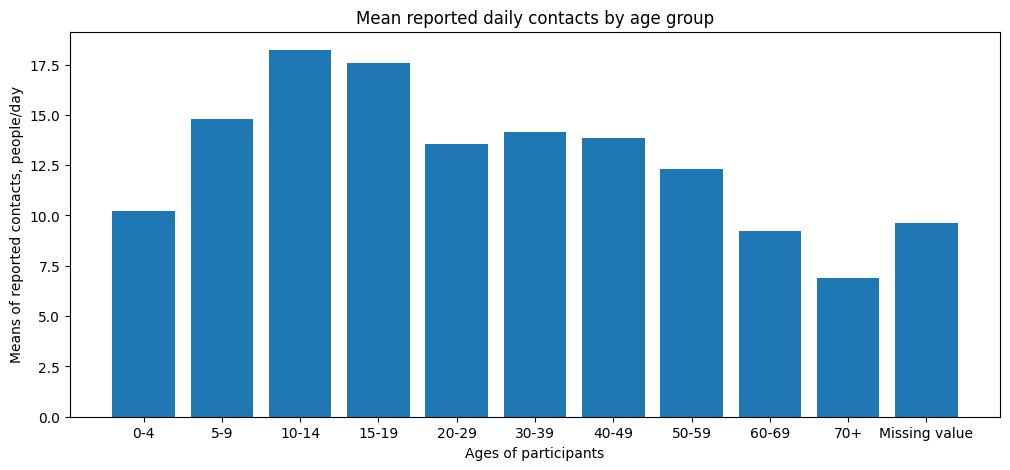

In [34]:
# The original reported contacts/ age distribution:
ages = ("0-4", "5-9", "10-14", "15-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+", "Missing value")
number_of_participants = [660, 661, 713, 685, 879, 815, 908, 906, 728, 270, 65]
mean_reported_contacts = [10.21, 14.81, 18.22, 17.58, 13.57, 14.14, 13.83, 12.30, 9.21, 6.89, 9.63]
standard_deviation_contacts = [7.65, 10.09, 12.27, 12.03, 10.60, 10.15, 10.86, 10.23, 7.96, 5.83, 9.05]

plt.figure(figsize= (12, 5))
plt.bar(ages, mean_reported_contacts)
plt.xlabel("Ages of participants")
plt.ylabel("Means of reported contacts, people/day")
plt.title("Mean reported daily contacts by age group")
plt.show()

**The random variable:**

X  = total number of social contacts under one day reported by an average individual.

According to the article, the contact can be physical or non-physical. If the participant meets the same person several times during the day, it counts as one contact.

**What the paper does:**

The paper presents a population-based prospective survey, where 7290 participants recorded their mixing patterns (social contacts)for one day.

Different types of contacts were identified, and different parameters are associated with different average rates of contact. The categories recorded were age, day of the week, gender, country, and household size.

The purpose of the survey is to allow modelling of transmission of infectious diseases that spread through close-contact.

The authors used negative binomial regression to analyse contact counts.

**The generative model proposed:**
 Negative Binomial Distribution

We chose this as contacts are independent from each other. The rates of daily contacts also from person to person, even within the same age groups. A negative binomial distribution allows for this variation.

To simulate one participant, we draw one contact count from the negative binomial distribution for their age group. We repeat this for all participants.

We use the same model for both age groups, with separate parameter values.

**Parameters and assumptions**

Each age group has two parameters:

- μ: the expected number of contacts per person per day.
- r: a positive, dimensionless parameter controlling variation. At the same μ, a smaller r gives more variation.

For this model:

The expected value for a discrete random variable is the mean
$$
E[X] = \mu
$$

The variance for a discrete random variable:
$$
\mathrm{Var}(X) = \mu + \frac{\mu^2}{r}
$$

Our main quantity of interest is to examine the difference between the mean for participants in the age group 10-14 and 70+

$$
\Delta = \mu_{10–14} - \mu_{70+}
$$

Assumptions:
- Participants are treated as independent observations.
- Within each age group, the same model describes all participants.
- We do not seperately model the other factors: countries, household size, weekdays, or gender of participants.

In [35]:
import math
import matplotlib.pyplot as plt


Binning our data (leaving out the values for missing values of ages):

In [36]:
age_bins = ["0-4","5-9","10-14","15-19","20-29","30-39","40-49","50-59","60-69","70+"]
n_part = np.array([660, 661, 713, 685, 879, 815, 908, 906, 728, 270])
mean_contacts = np.array([10.21, 14.81, 18.22, 17.58, 13.57, 14.14, 13.83, 12.30, 9.21, 6.89])
standard_deviation_contacts = np.array([7.65, 10.09, 12.27, 12.03, 10.60, 10.15, 10.86, 10.23, 7.96, 5.83])
variance_contacts = standard_deviation_contacts**2

In [47]:
# Index for the groups
idx_young = 2   # 10-14
idx_old = 9     # 70+

# Extract per-group
n_y = n_part[idx_young]; mu_y = mean_contacts[idx_young]; var_y = var_contacts[idx_young]
n_o = n_part[idx_old];  mu_o = mean_contacts[idx_old];  var_o = var_contacts[idx_old]

# Standard variance for groups
se_y = np.sqrt(var_y / n_y)
se_o = np.sqrt(var_o / n_o)

In [46]:
# Method-of-moments for negative binomial dispersion k/ group: var = mu + mu^2/k  =>  k = mu^2 / (var - mu)
def estimate_k(mu, var):
    if var <= mu:
        return np.inf
    return mu**2 / (var - mu)

k_y = estimate_k(mu_y, var_y)
k_o = estimate_k(mu_o, var_o)

# Approximate difference in mean and z-test
diff = mu_y - mu_o
se_diff = np.sqrt(se_y**2 + se_o**2)
z = diff / se_diff
p_two = 2 * (1 - 0.5 * (1 + erf(abs(z) / sqrt(2))))

print("Group 10-14: n = {}, mean = {:.3f}, sd = {:.3f}, se = {:.4f}, k = {:.3f}".format(
    n_y, mu_y, np.sqrt(var_y), se_y, k_y))
print("Group 70+:  n = {}, mean = {:.3f}, sd = {:.3f}, se = {:.4f}, k = {:.3f}".format(
    n_o, mu_o, np.sqrt(var_o), se_o, k_o))
print("\nSDifference in mean (10-14 vs. 70+): {:.3f}".format(diff))
print("SE(diff) = {:.4f}, z = {:.3f}, two-sided p-value ≈ {:.3e}".format(se_diff, z, p_two))

Group 10-14: n = 713, mean = 18.220, sd = 12.270, se = 0.4595, k = 2.509
Group 70+:  n = 270, mean = 6.890, sd = 5.830, se = 0.3548, k = 1.752

SDifference in mean (10-14 vs. 70+): 11.330
SE(diff) = 0.5806, z = 19.516, two-sided p-value ≈ 0.000e+00


**Simulate individuals from Gamma-Poisson to illustrate distributions**

In [42]:
rng = np.random.default_rng(2026)
def simulate_nb(mu, k, N):
    if np.isinf(k):
        return rng.poisson(lam=mu, size=N)
    lam = rng.gamma(shape=k, scale=mu/k, size=N)
    return rng.poisson(lam)

Nsim = 20000
sim_y = simulate_nb(mu_y, k_y, Nsim)
sim_o = simulate_nb(mu_o, k_o, Nsim)

print("\nSimulated (N={}):".format(Nsim))
print("  10-14: sim mean {:.3f}, sim sd {:.3f}, frac >20 = {:.4f}".format(sim_y.mean(), sim_y.std(ddof=1), (sim_y>20).mean()))
print("  70+:  sim mean {:.3f}, sim sd {:.3f}, frac >20 = {:.4f}".format(sim_o.mean(), sim_o.std(ddof=1), (sim_o>20).mean()))

Group 10-14: n = 713, mean = 18.220, sd = 12.270, se = 0.4595, k = 2.509
Group 70+:  n = 270, mean = 6.890, sd = 5.830, se = 0.3548, k = 1.752

SDifference in mean (10-14 vs. 70+): 11.330
SE(diff) = 0.5806, z = 19.516, two-sided p-value ≈ 0.000e+00

Simulated (N=20000):
  10-14: sim mean 18.194, sim sd 12.184, frac >20 = 0.3504
  70+:  sim mean 6.908, sim sd 5.910, frac >20 = 0.0328


**Plot for simulated negative binomial distribution**

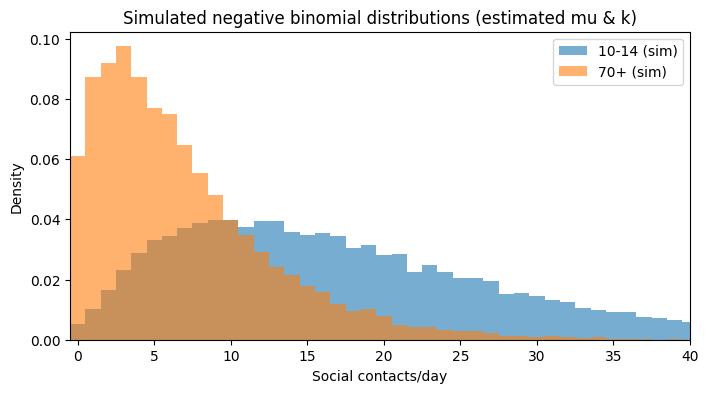

In [41]:
plt.figure(figsize=(8,4))
maxx = max(sim_y.max(), sim_o.max(), 40)
bins = np.arange(0, min(maxx,60)+1) - 0.5
plt.hist(sim_y, bins=bins, density=True, alpha=0.6, label='10-14 (sim)')
plt.hist(sim_o, bins=bins, density=True, alpha=0.6, label='70+ (sim)')
plt.xlim(-0.5, 40)
plt.xlabel("Social contacts/day")
plt.ylabel("Density")
plt.legend()
plt.title("Simulated negative binomial distributions (estimated mu & k)")
plt.show()

Simulating without formula

Proposed generative model

Likelihood & fitting